# SOM — Segmentación de Clientes

---

**Autor:** Borja Mora Méndez  
**Contacto:** borja.mora.mendez@gmail.com · [LinkedIn](https://linkedin.com/in/borjamoramendez)  
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)  
**Categoría:** Machine Learning · No supervisado · Redes Neuronales · SOM

---

### Objetivo

Aplicar un **Self-Organizing Map (SOM)** para descubrir segmentos naturales dentro de una base de clientes y visualizar cómo se relacionan entre sí en un espacio 2D.

### Contexto de negocio

Una cadena de retail quiere segmentar su base de **500 clientes** para personalizar campañas de marketing. El análisis utiliza cuatro variables de comportamiento: **recencia, frecuencia, gasto promedio y uso de descuentos**.


## 1️. Setup: librerías y configuración visual

In [ ]:
# Librerías base
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# SOM y clustering
from minisom import MiniSom
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Estilo visual común del portfolio
PURPLE = "#7a7bff"
GREEN  = "#6E7F5B"
RED    = "#C2412E"
GRAY   = "#F4EFE6"
INK    = "#2B2118"
MUTED  = "#bfbfbf"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlecolor": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.family": "sans-serif",
    "font.size": 10,
    "grid.color": "#f0f0f0",
    "grid.linewidth": 0.5,
})

pd.set_option("display.max_columns", None)


Entorno configurado correctamente.


## 2. Carga de datos



In [2]:
# Carga del dataset
df = pd.read_excel("dataset_SOM.xlsx")

print(f"Registros: {df.shape[0]:,} | Variables: {df.shape[1]}")
df.head()


Registros: 500 | Variables: 4


,Recencia_Dias,Frecuencia_Semanal,Gasto_Promedio,Uso_Descuentos
0,75.553184,0.319784,43.439459,25.526450
1,3.983115,6.054010,127.245935,10.296509
2,71.283276,0.137565,28.826940,31.283447
3,12.087373,2.662964,25.796198,90.276212
4,4.617521,5.330605,100.968996,11.002392


## 3. EDA: Análisis Exploratorio de Datos

Antes de entrenar el SOM comprobamos la escala de las variables, posibles valores nulos y las relaciones entre los comportamientos de compra.


In [3]:
# Estadísticos descriptivos
display(df.describe().round(2))

print(f"\nValores nulos: {df.isnull().sum().sum()}")


,Recencia_Dias,Frecuencia_Semanal,Gasto_Promedio,Uso_Descuentos
count,500.00,500.00,500.00,500.00
mean,29.64,2.97,59.26,46.82
std,30.21,2.02,41.42,32.22
min,0.00,0.00,13.79,4.17
25%,5.19,0.69,25.80,13.78
50%,14.82,2.93,41.43,32.54
75%,72.14,4.86,109.72,83.45
max,83.54,7.14,150.21,100.59



Valores nulos: 0


In [4]:
# Tipos, nulos y valores únicos
info = pd.DataFrame({
    "Tipo": df.dtypes,
    "Nulos": df.isnull().sum(),
    "% Nulos": (df.isnull().sum() / len(df) * 100).round(2),
    "Únicos": df.nunique()
})

info


,Tipo,Nulos,% Nulos,Únicos
Recencia_Dias,float64,0,0.0,500
Frecuencia_Semanal,float64,0,0.0,499
Gasto_Promedio,float64,0,0.0,500
Uso_Descuentos,float64,0,0.0,500


### Distribución de las variables

El SOM utiliza distancias entre observaciones. Por eso, además de entender las distribuciones, será necesario **estandarizar las cuatro variables antes del entrenamiento**.


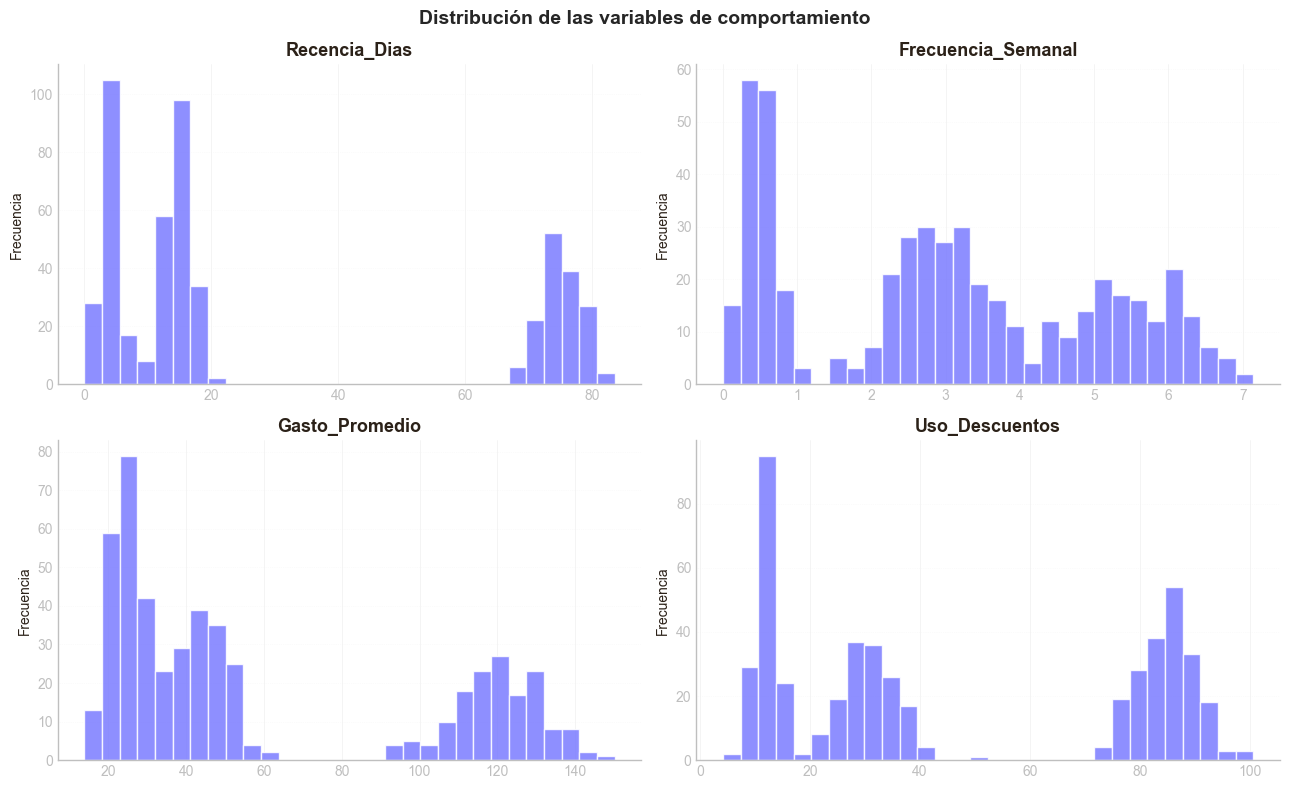

In [5]:
# Distribución de las variables
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, col in zip(axes.flat, df.columns):
    ax.hist(
        df[col],
        bins=30,
        color=PURPLE,
        edgecolor="white",
        alpha=0.85
    )
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")
    ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.suptitle("Distribución de las variables de comportamiento", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


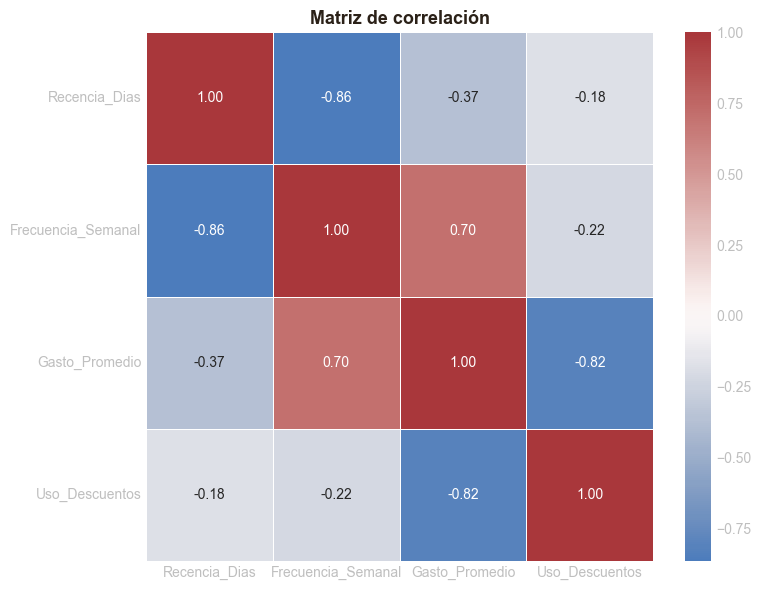

In [6]:
# Matriz de correlación
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()


### Lectura del EDA

Las variables describen dimensiones diferentes del comportamiento del cliente. La estandarización será clave para evitar que una variable domine el cálculo de distancias únicamente por utilizar una escala numérica mayor.


## 4. Preparación de datos

El SOM se basa en distancias. Estandarizamos cada variable para que todas tengan **media 0 y desviación estándar 1**, manteniendo el mismo peso inicial en el entrenamiento.


In [7]:
# Estandarización
scaler = StandardScaler()
X = scaler.fit_transform(df)

print(f"Shape escalado: {X.shape}")
print(f"Media: {X.mean(axis=0).round(2)}")
print(f"Desviación estándar: {X.std(axis=0).round(2)}")


Shape escalado: (500, 4)
Media: [-0.  0. -0.  0.]
Desviación estándar: [1. 1. 1. 1.]


## 5. Modelo principal

Se construye una rejilla de **10 × 10 = 100 neuronas**. Cada neurona aprende un prototipo de cliente y el algoritmo coloca perfiles similares en posiciones próximas del mapa.

El objetivo no es predecir una variable, sino **descubrir la estructura de la base de clientes**.


In [8]:
# Entrenamiento del SOM
np.random.seed(42)

som_x, som_y = 10, 10

som = MiniSom(
    x=som_x,
    y=som_y,
    input_len=X.shape[1],
    sigma=1.5,
    learning_rate=0.5,
    neighborhood_function="gaussian",
    random_seed=42
)

som.random_weights_init(X)
som.train_random(X, num_iteration=5000)

print("Entrenamiento completado: 5.000 iteraciones")
print(f"Error de cuantización: {som.quantization_error(X):.4f}")


Entrenamiento completado: 5.000 iteraciones
Error de cuantización: 0.1123


### 5.1. U-Matrix — estructura y separación

La **U-Matrix** representa la distancia entre neuronas vecinas. Las zonas con valores altos actúan como fronteras: indican cambios más fuertes entre perfiles de clientes.


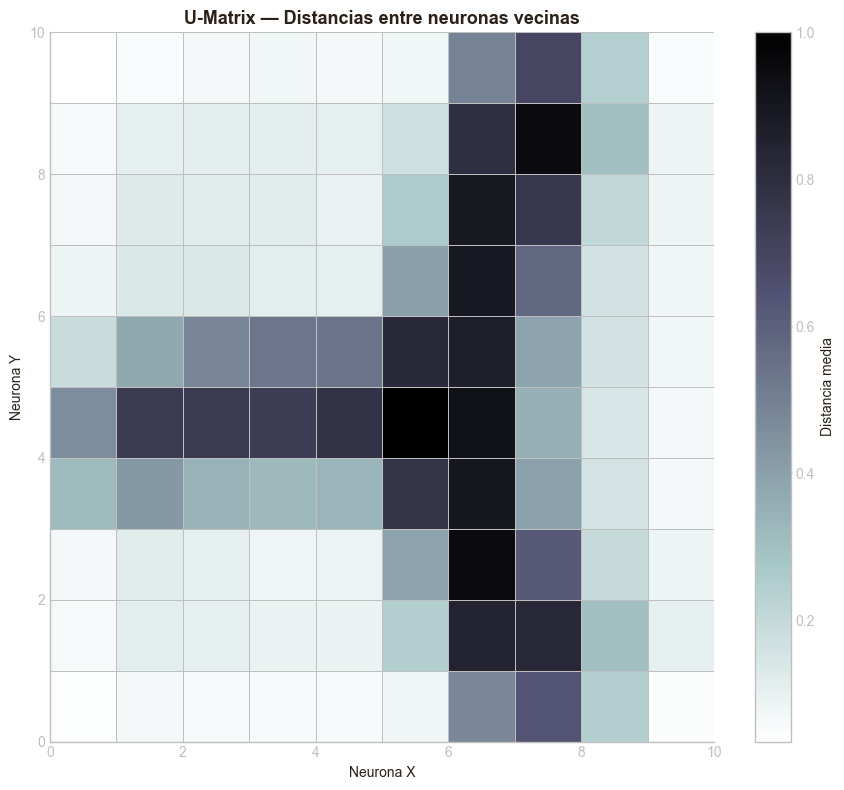

In [9]:
# U-Matrix
umatrix = som.distance_map()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.pcolormesh(
    umatrix.T,
    cmap="bone_r",
    edgecolors=MUTED,
    linewidth=0.5
)

ax.set_title("U-Matrix — Distancias entre neuronas vecinas")
ax.set_xlabel("Neurona X")
ax.set_ylabel("Neurona Y")
plt.colorbar(im, ax=ax, label="Distancia media")

plt.tight_layout()
plt.show()


### 5.2. Mapa de frecuencia

Este mapa muestra cuántos clientes terminan asociados a cada neurona. Permite localizar las zonas más pobladas del espacio de comportamiento.


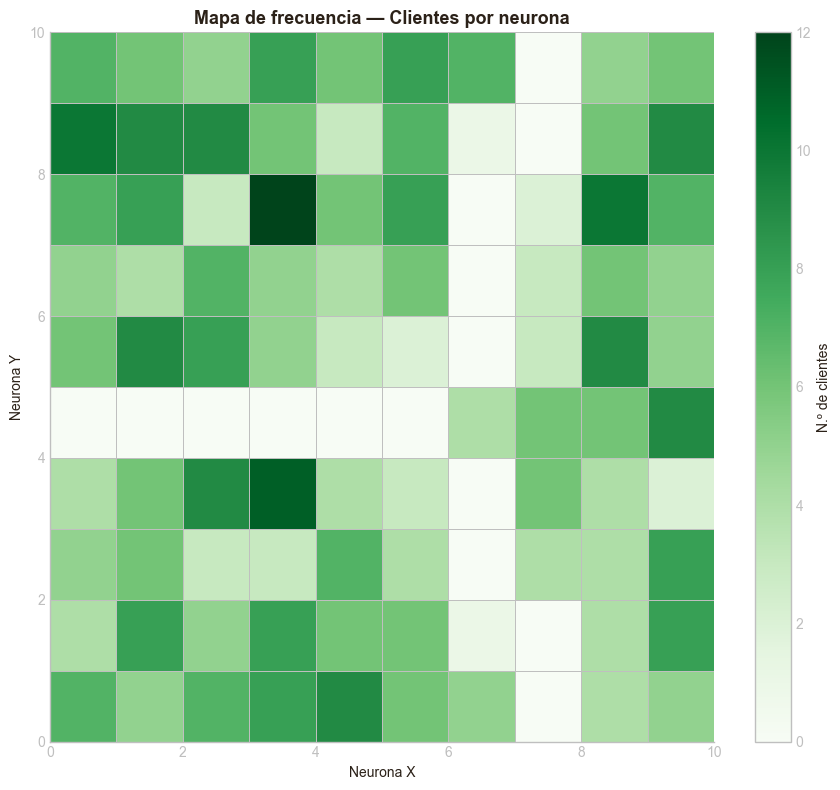

In [10]:
# Mapa de frecuencia
freq_map = np.zeros((som_x, som_y))

for row in X:
    winner = som.winner(row)
    freq_map[winner[0], winner[1]] += 1

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.pcolormesh(
    freq_map.T,
    cmap="Greens",
    edgecolors=MUTED,
    linewidth=0.5
)

ax.set_title("Mapa de frecuencia — Clientes por neurona")
ax.set_xlabel("Neurona X")
ax.set_ylabel("Neurona Y")
plt.colorbar(im, ax=ax, label="N.º de clientes")

plt.tight_layout()
plt.show()


### 5.3. Component Planes

Cada **Component Plane** muestra cómo se distribuye una variable dentro del mapa. La lectura conjunta permite entender qué características definen cada región y cómo se relacionan entre ellas.


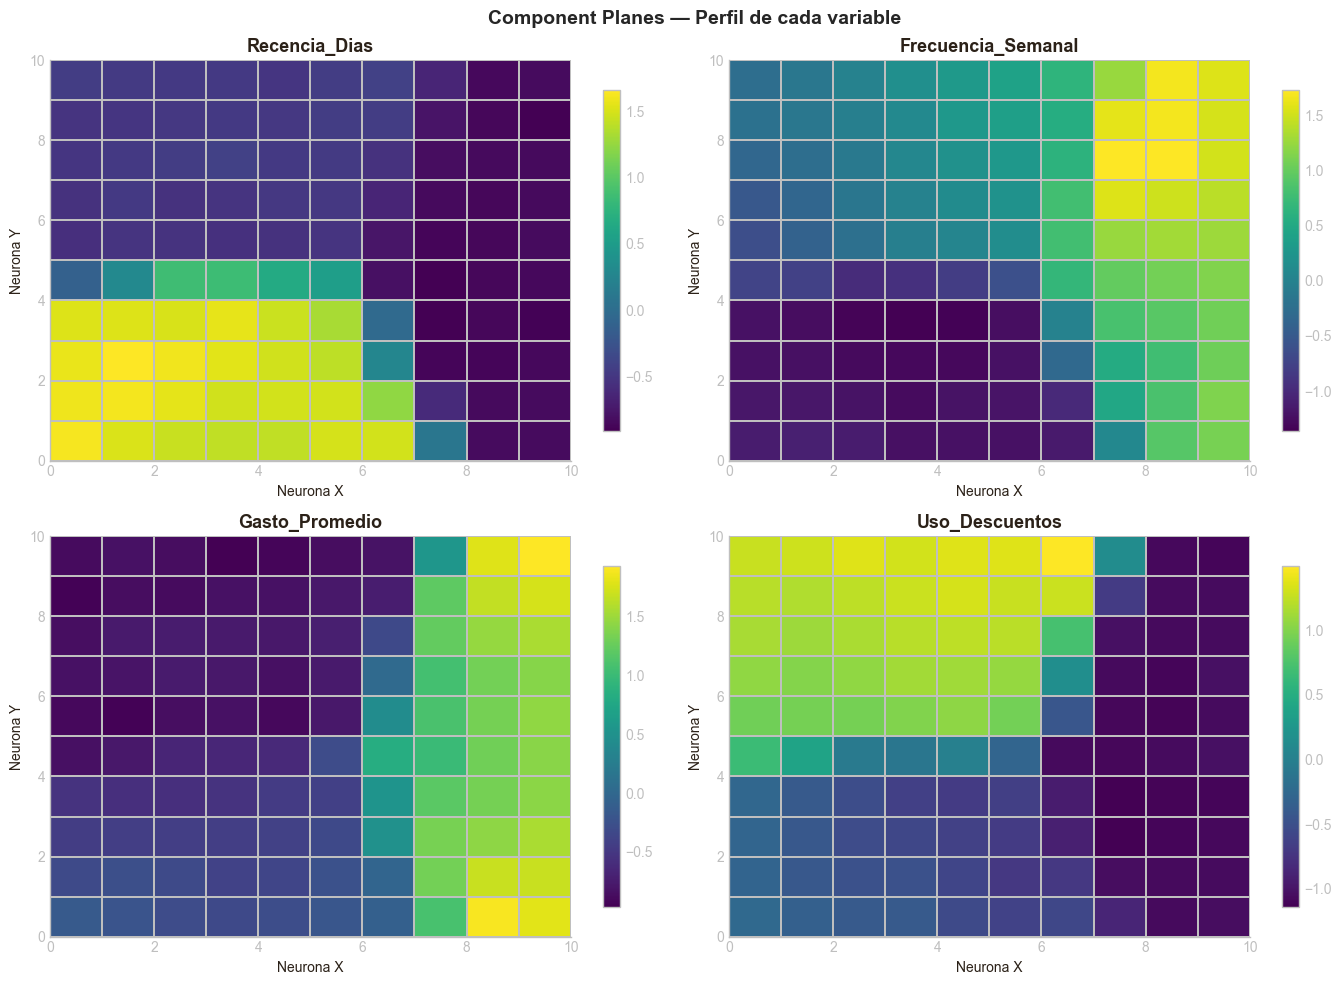

In [11]:
# Component planes
weights = som.get_weights()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, i, col in zip(axes.flat, range(X.shape[1]), df.columns):
    im = ax.pcolormesh(
        weights[:, :, i].T,
        cmap="viridis",
        edgecolors=MUTED,
        linewidth=0.3
    )
    ax.set_title(col)
    ax.set_xlabel("Neurona X")
    ax.set_ylabel("Neurona Y")
    plt.colorbar(im, ax=ax, shrink=0.85)

plt.suptitle("Component Planes — Perfil de cada variable", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Segmentación — K-Means sobre el SOM

El SOM organiza los perfiles, pero no genera por sí mismo etiquetas de cluster. Aplicamos **K-Means sobre los 100 vectores de pesos de las neuronas** para convertir el mapa en segmentos interpretables.


In [12]:
# Selección de k mediante Silhouette
weights_flat = som.get_weights().reshape(-1, X.shape[1])

silhouettes = []

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(weights_flat)
    score = silhouette_score(weights_flat, labels)
    silhouettes.append((k, score))

    print(f"k={k}: Silhouette = {score:.3f}")

best_k = max(silhouettes, key=lambda x: x[1])[0]
print(f"\nMejor k: {best_k}")


k=2: Silhouette = 0.582
k=3: Silhouette = 0.755
k=4: Silhouette = 0.701
k=5: Silhouette = 0.648
k=6: Silhouette = 0.667
k=7: Silhouette = 0.588

Mejor k: 3


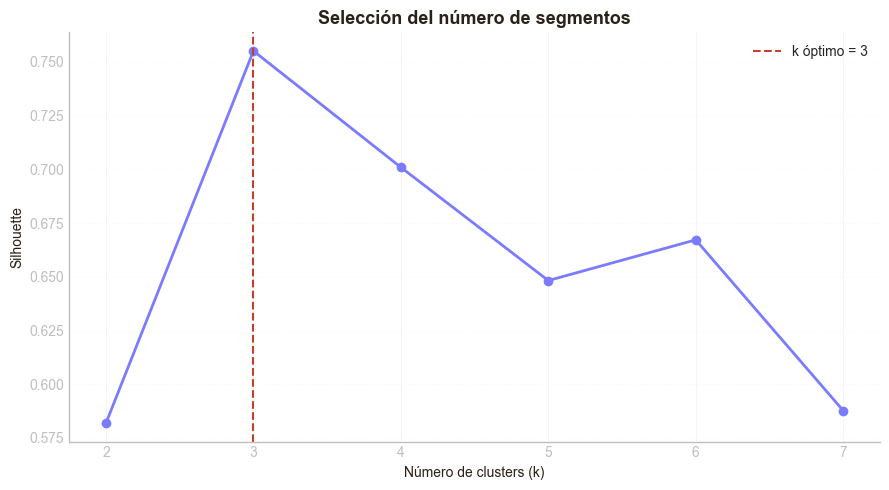

In [13]:
# Visualización de Silhouette
sil_df = pd.DataFrame(silhouettes, columns=["k", "Silhouette"])

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    sil_df["k"],
    sil_df["Silhouette"],
    marker="o",
    linewidth=2,
    color=PURPLE
)

ax.axvline(
    best_k,
    color=RED,
    linestyle="--",
    linewidth=1.5,
    label=f"k óptimo = {best_k}"
)

ax.set_title("Selección del número de segmentos")
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Silhouette")
ax.legend()
ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()


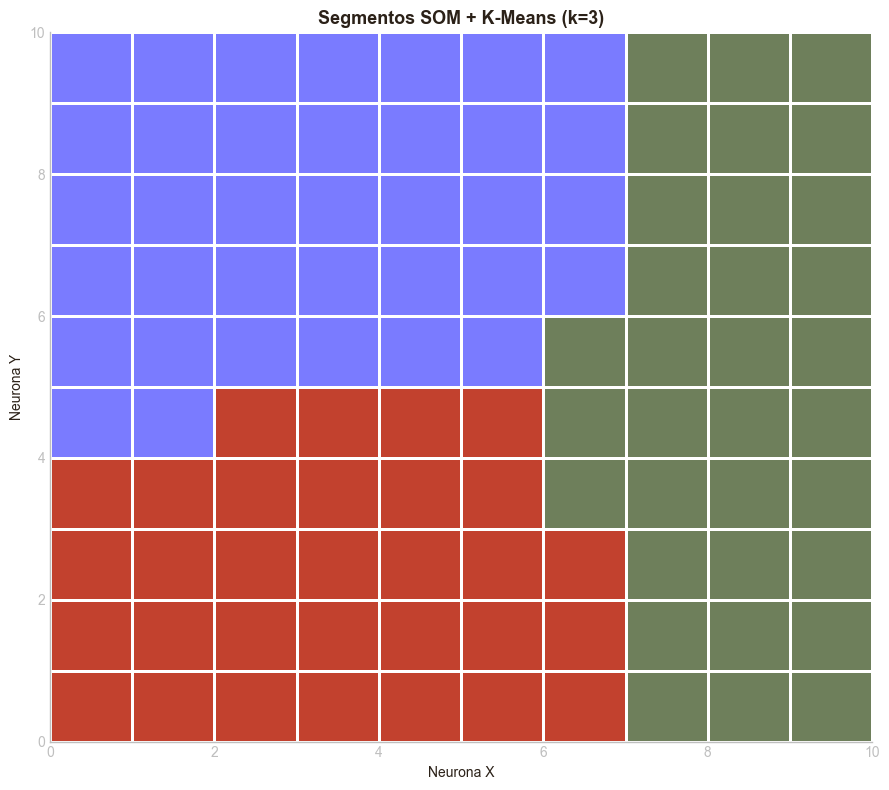

In [14]:
# K-Means sobre los pesos del SOM
km_som = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_som.fit_predict(weights_flat).reshape(som_x, som_y)

# Asignar cluster a cada cliente según su BMU
df["Cluster_SOM"] = [
    cluster_labels[som.winner(row)]
    for row in X
]

# Mapa de segmentos
from matplotlib.colors import ListedColormap
segment_colors = [PURPLE, GREEN, RED, "#D4A72C", "#5B8FA8", "#8C6BB1", "#7F8C8D"]
segment_cmap = ListedColormap(segment_colors[:best_k])

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.pcolormesh(
    cluster_labels.T,
    cmap=segment_cmap,
    edgecolors="white",
    linewidth=0.8
)

ax.set_title(f"Segmentos SOM + K-Means (k={best_k})")
ax.set_xlabel("Neurona X")
ax.set_ylabel("Neurona Y")

plt.tight_layout()
plt.show()


## 7. Modelo de referencia — K-Means directo

Para comprobar qué aporta el SOM, aplicamos el mismo número de clusters directamente sobre los clientes estandarizados. Así podemos comparar **K-Means directo** frente a **SOM + K-Means**.


In [15]:
# K-Means directo sobre los clientes
km_direct = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["Cluster_KMeans"] = km_direct.fit_predict(X)

sil_som = silhouette_score(X, df["Cluster_SOM"])
sil_km = silhouette_score(X, df["Cluster_KMeans"])

comparison = pd.DataFrame({
    "Método": ["SOM + K-Means", "K-Means directo"],
    "Silhouette": [sil_som, sil_km]
})

display(comparison.style.format({"Silhouette": "{:.3f}"}))


,Método,Silhouette
0,SOM + K-Means,0.852
1,K-Means directo,0.852


## 8. Perfilado de los segmentos

La segmentación solo es útil si los clusters pueden traducirse a **perfiles de cliente reconocibles**. Comparamos las medias de las cuatro variables para identificar qué diferencia a cada segmento.


In [16]:
# Perfil medio de cada segmento
segment_cols = [
    "Recencia_Dias",
    "Frecuencia_Semanal",
    "Gasto_Promedio",
    "Uso_Descuentos"
]

perfil = (
    df.groupby("Cluster_SOM")[segment_cols]
      .mean()
      .round(1)
)

print("Perfil medio por segmento:")
display(perfil)

print("Distribución de clientes:")
display(
    df["Cluster_SOM"]
    .value_counts()
    .sort_index()
    .rename("Clientes")
    .to_frame()
)


Perfil medio por segmento:


,Recencia_Dias,Frecuencia_Semanal,Gasto_Promedio,Uso_Descuentos
Cluster_SOM,,,,
0,14.8,2.9,24.7,84.8
1,4.0,5.5,120.1,12.1
2,75.1,0.5,44.5,30.9


Distribución de clientes:


,Clientes
Cluster_SOM,
0,200
1,150
2,150


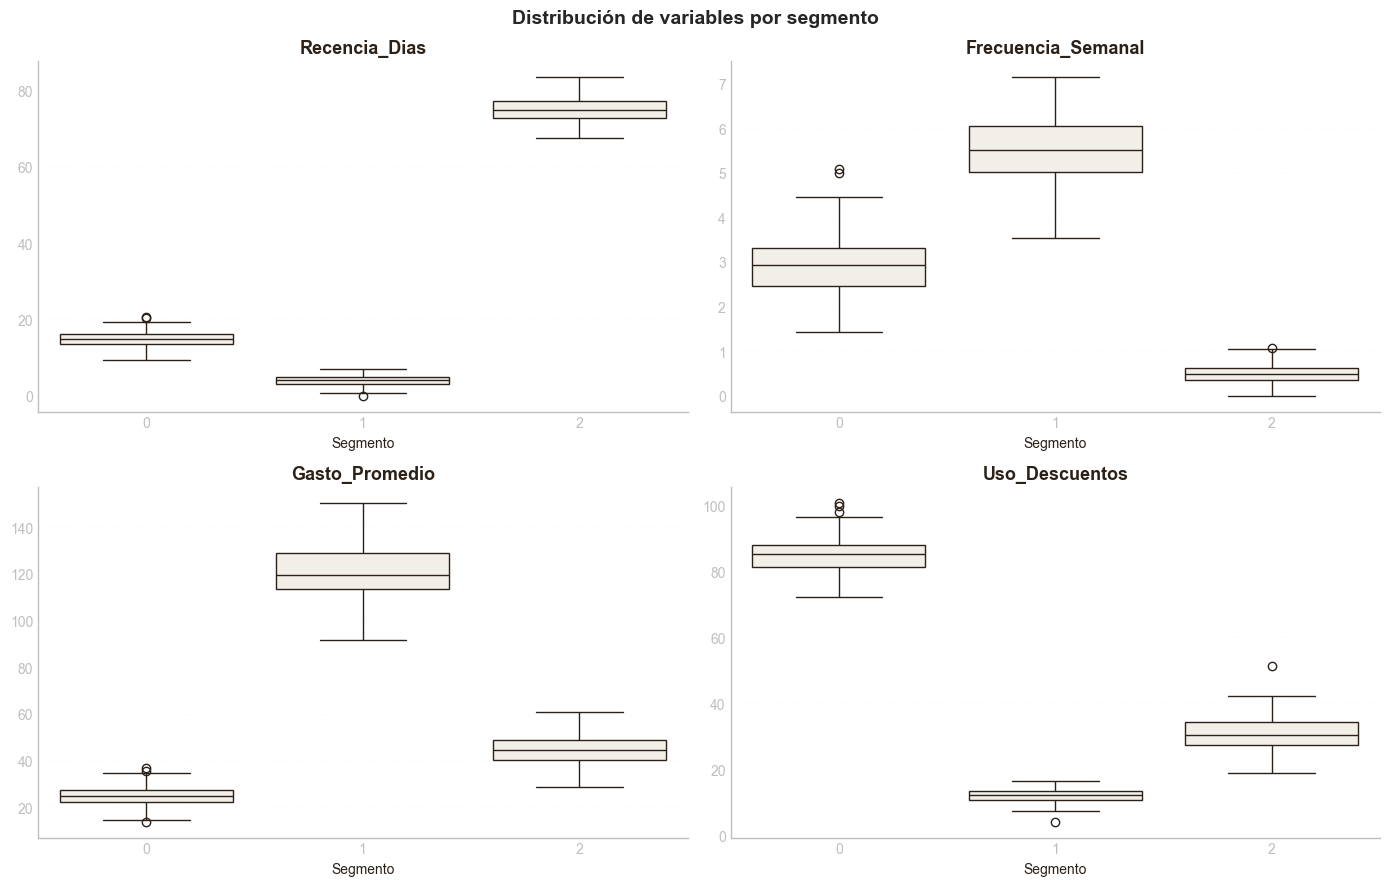

In [17]:
# Distribución de las variables por segmento
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, col in zip(axes.flat, segment_cols):
    sns.boxplot(
        data=df,
        x="Cluster_SOM",
        y=col,
        color=GRAY,
        linecolor=INK,
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel("Segmento")
    ax.set_ylabel("")
    ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.suptitle("Distribución de variables por segmento", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


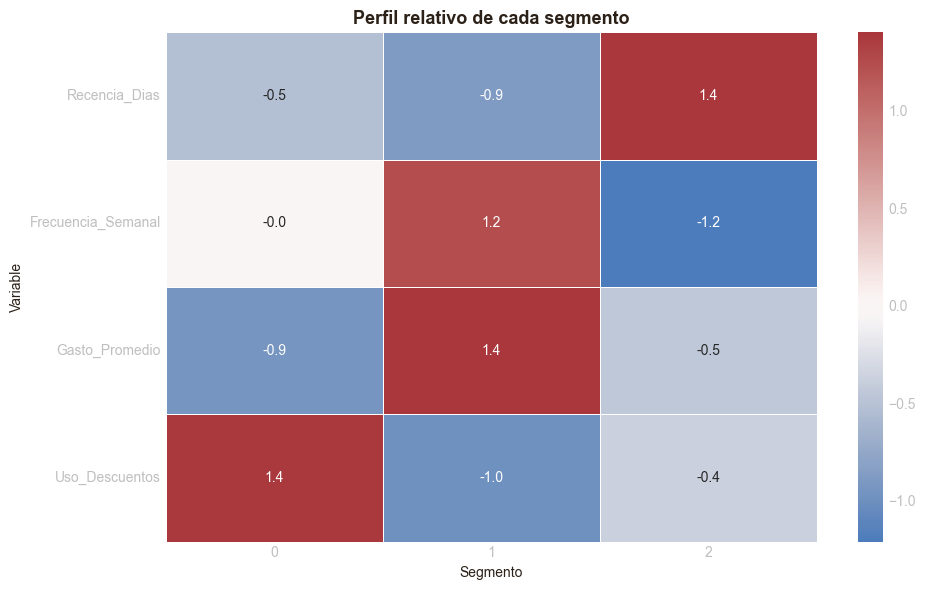

In [18]:
# Heatmap de perfiles estandarizados
perfil_z = (perfil - perfil.mean()) / perfil.std(ddof=0)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    perfil_z.T,
    annot=True,
    fmt=".1f",
    cmap="vlag",
    center=0,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Perfil relativo de cada segmento")
ax.set_xlabel("Segmento")
ax.set_ylabel("Variable")

plt.tight_layout()
plt.show()


## 9. Comparación de métodos

| Método | Silhouette | Topología | Interpretabilidad |
|:-------|:-----------|:----------|:------------------|
| **SOM + K-Means** | Calculada en test | Sí, mapa 2D | Alta |
| **K-Means directo** | Calculada en test | No | Media |

La métrica **Silhouette** permite comparar la separación interna de los segmentos. El valor diferencial del SOM, sin embargo, no está únicamente en esta métrica: aporta una representación topológica que permite estudiar **qué segmentos son vecinos y qué zonas están separadas por fronteras**.


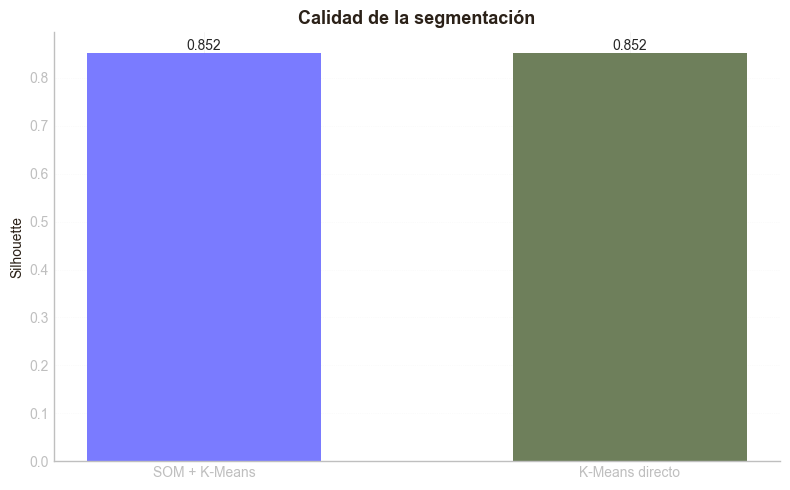

In [19]:
# Comparación visual de Silhouette
fig, ax = plt.subplots(figsize=(8, 5))

methods = ["SOM + K-Means", "K-Means directo"]
scores = [sil_som, sil_km]

bars = ax.bar(
    methods,
    scores,
    width=0.55,
    color=[PURPLE, GREEN]
)

ax.set_title("Calidad de la segmentación")
ax.set_ylabel("Silhouette")
ax.grid(axis="y", linestyle=":", alpha=0.5)

for bar, value in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


## 10. Insights y recomendaciones accionables

### Hallazgo clave

Los **Component Planes** permiten identificar cómo se distribuyen frecuencia, gasto, recencia y uso de descuentos dentro del mapa. Las regiones con perfiles similares quedan próximas, mientras que las fronteras de la U-Matrix ayudan a localizar cambios relevantes entre comportamientos.

### Recomendaciones

**1. Campañas personalizadas por segmento — impacto alto**  
Adaptar mensajes, ofertas y canales a las características de cada cluster en lugar de tratar a toda la base de clientes de la misma forma.

**2. Monitorizar migraciones entre segmentos — impacto medio**  
Repetir el SOM periódicamente permite detectar clientes que cambian de comportamiento y, especialmente, aquellos que evolucionan hacia perfiles de menor frecuencia o mayor recencia.

**3. Llevar el mapa a un dashboard — impacto medio**  
Una visualización interactiva permitiría a marketing explorar segmentos, tamaños y perfiles sin necesidad de trabajar directamente con el notebook.


## 11. Conclusión

El SOM aporta una forma diferente de segmentar clientes: no solo crea grupos, sino que **organiza los perfiles en un mapa donde la proximidad tiene significado**. La combinación **SOM + K-Means** permite aprovechar esa estructura topológica y convertirla en segmentos accionables.

El análisis muestra que la segmentación debe interpretarse conjuntamente con los **Component Planes, la U-Matrix y el perfil medio de cada cluster**. La métrica Silhouette sirve como referencia para comparar con K-Means directo, pero el principal valor del SOM está en hacer visible la estructura de comportamiento que hay detrás de los segmentos.

### Aplicación de negocio

La siguiente evolución natural sería incorporar la segmentación a un proceso periódico de CRM: **asignar clientes → identificar cambios de segmento → activar campañas → medir respuesta → volver a entrenar el mapa**.
